In [62]:
from pathlib import Path
import xgboost as xgb
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score
from sklearn.model_selection import RandomizedSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
import seaborn as sns
import matplotlib.pyplot as plt

In [51]:
DATA_DIR = Path.cwd().parent / "data"
df = pd.read_csv(DATA_DIR / "processed" / "cleaned_taxi_data.csv")
df.head(5)

,index_left,id,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration,BoroName
0,4217,id1693416,2,2016-01-12 22:57:13,2016-01-12 23:33:06,1,-73.979324,40.727631,-74.074028,40.640224,N,35.883333,Staten Island
1,16494,id1973056,2,2016-03-22 15:35:52,2016-03-22 16:53:17,1,-73.789642,40.647121,-74.135986,40.624981,N,77.416667,Staten Island
2,17985,id3759847,2,2016-02-04 22:00:26,2016-02-04 22:48:18,2,-73.984749,40.742130,-74.076393,40.599159,N,47.866667,Staten Island
3,19015,id3330882,2,2016-04-02 08:47:43,2016-04-02 08:50:23,1,-74.073433,40.615421,-74.073433,40.615421,N,2.666667,Staten Island
4,19701,id0778469,1,2016-01-01 19:46:50,2016-01-01 20:33:26,1,-73.991974,40.749928,-74.115303,40.574230,N,46.600000,Staten Island


In [52]:
def haversine_form(lat1,long1,lat2,long2):
    lat1 , long1,lat2,long2 = map(np.radians, [lat1, long1, lat2, long2])
    dlat = lat2-lat1
    dlong = long2-long1
    a  = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2)*np.sin(dlong/2)**2
    c = 2 * np.arcsin(np.sqrt(a))
    r = 3956
    return c*r

In [53]:
df['pickup_datetime'] = pd.to_datetime(df['pickup_datetime'])
df.drop(['vendor_id','dropoff_datetime','store_and_fwd_flag'],axis =1,inplace=True)
df['distance'] =  haversine_form(df['pickup_latitude'],df['pickup_longitude'],df['dropoff_latitude'],df['dropoff_longitude'])
df['day_of_week'] = df['pickup_datetime'].dt.day_of_week
df['pickup_hour'] = df['pickup_datetime'].dt.hour
df['is_rush_hour'] = df['pickup_hour'].isin([7,8,9,16,17,18,19]).astype(int)
df['is_weekend'] = df['day_of_week'].isin([5,6]).astype(int)

In [54]:
X = df.drop(['trip_duration','id','pickup_datetime','index_left'],axis=1)
y = df['trip_duration']
categorical = X.select_dtypes(include=['str']).columns.to_list()
X[categorical]= X[categorical].astype('category')
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42,shuffle=True)


In [55]:
X.info()

<class 'pandas.DataFrame'>
RangeIndex: 1442002 entries, 0 to 1442001
Data columns (total 11 columns):
 #   Column             Non-Null Count    Dtype   
---  ------             --------------    -----   
 0   passenger_count    1442002 non-null  int64   
 1   pickup_longitude   1442002 non-null  float64 
 2   pickup_latitude    1442002 non-null  float64 
 3   dropoff_longitude  1442002 non-null  float64 
 4   dropoff_latitude   1442002 non-null  float64 
 5   BoroName           1442002 non-null  category
 6   distance           1442002 non-null  float64 
 7   day_of_week        1442002 non-null  int32   
 8   pickup_hour        1442002 non-null  int32   
 9   is_rush_hour       1442002 non-null  int64   
 10  is_weekend         1442002 non-null  int64   
dtypes: category(1), float64(5), int32(2), int64(3)
memory usage: 100.4 MB


In [56]:
XGB_PARAM  = {'lambda': 3.3633401045158903e-07,
               'alpha': 0.01121276561148217, 
               'subsample': 0.9405758686374284, 
               'max_depth': 7,
                 'colsample_bytree': 0.9054986003043914}

HIST_PARAM = {'learning_rate': 0.20822254137715343,
               'l2_regularization': 1.5234018422544593,
                 'max_leaf_nodes': 100,
                   'max_depth': 10, 
                   'min_samples_leaf': 33}

In [57]:
categorical_enc = ColumnTransformer([("category",OneHotEncoder(sparse_output=False),categorical)],remainder='passthrough',verbose_feature_names_out=False)
pipeline = Pipeline(
    [('encoder',categorical_enc),
     ('modle',LinearRegression())]
)

In [58]:
from sklearn.ensemble import VotingRegressor

ensemble = VotingRegressor([
    ('xgb', xgb.XGBRegressor(**XGB_PARAM,enable_categorical =True, random_state=42)),
    ('lr',pipeline),
    ('hgb', HistGradientBoostingRegressor(**HIST_PARAM,categorical_features=categorical))
])


In [59]:
models = {"Linear":LinearRegression(),
          "Hist":HistGradientBoostingRegressor(**HIST_PARAM,categorical_features=categorical,random_state=42)
          ,"xgboost":xgb.XGBRegressor(**XGB_PARAM,enable_categorical =True,random_state=42,n_jobs=-1),
          "VotingRegressor":ensemble}
result = {}
for i in models:
    if i == "Linear":
        X_dummy =  pd.get_dummies(X_train, columns=categorical, drop_first=True)
        X_test_d = pd.get_dummies(X_test, columns=categorical, drop_first=True)
        models[i].fit(X_dummy,y_train)
        prediction = models[i].predict(X_test_d)
        mae = round(mean_absolute_error(y_test,prediction),2)
        result[i]=mae
    else:
        models[i].fit(X_train,y_train)
        prediction = models[i].predict(X_test)
        mae = round(mean_absolute_error(y_test,prediction),2)
        result[i]=mae

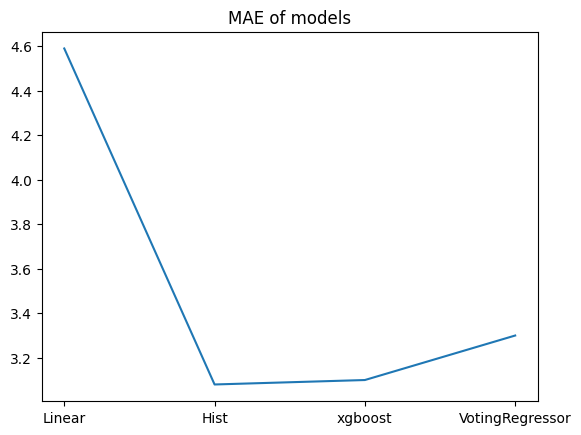

In [60]:
FIGURES_DIR = Path.cwd().parent / "reports" / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
sns.lineplot(result)
plt.title("MAE of models")
plt.savefig(FIGURES_DIR / "model_comp.png")